# 7. Medidas de Desempeño de Portafolios

## Ratios de información: ¿qué tan bien lo hizo mi portafolio?

Los **ratios de desempeño** permiten evaluar si el rendimiento de un portafolio compensa adecuadamente el riesgo asumido. No basta con mirar el rendimiento bruto: un portafolio que rindió 20% con altísima volatilidad puede ser peor que uno que rindió 12% con baja volatilidad.

En este cuaderno calculamos **6 ratios fundamentales** con datos reales:

| Ratio | ¿Qué mide? | Fórmula |
|---|---|---|
| **Sharpe** | Rendimiento por unidad de riesgo total ($\sigma$) | $\frac{R_p - R_f}{\sigma_p}$ |
| **Treynor** | Rendimiento por unidad de riesgo sistemático ($\beta$) | $\frac{R_p - R_f}{\beta_p}$ |
| **Alfa de Jensen** | Rendimiento en exceso vs. lo que predice el CAPM | $\alpha = R_p - [R_f + \beta_p(R_m - R_f)]$ |
| **Sortino** | Rendimiento por unidad de riesgo *a la baja* | $\frac{R_p - R_f}{\sigma_{downside}}$ |
| **Ratio de Información** | Rendimiento activo por unidad de tracking error | $\frac{R_p - R_b}{\sigma(R_p - R_b)}$ |
| **Modigliani (M²)** | Rendimiento ajustado al mismo riesgo del mercado | $M^2 = R_f + \frac{R_p - R_f}{\sigma_p} \cdot \sigma_m$ |

---

### Datos del ejemplo

Construiremos un **portafolio equiponderado** con 5 acciones reales y lo compararemos contra el **S&P 500** como benchmark.

## Paso 1 — Descargar datos y construir el portafolio

Descargamos precios de cierre de 5 acciones diversificadas por sector y del S&P 500 como benchmark:

| Ticker | Empresa | Sector |
|---|---|---|
| AAPL | Apple | Tecnología |
| JNJ | Johnson & Johnson | Salud |
| JPM | JPMorgan Chase | Financiero |
| XOM | ExxonMobil | Energía |
| PG | Procter & Gamble | Consumo básico |

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

# ─── Configuración ───
tickers = ["AAPL", "JNJ", "JPM", "XOM", "PG"]
benchmark = "^GSPC"
inicio = "2022-01-01"
fin = "2025-01-01"
rf_anual = 0.05                    # Tasa libre de riesgo anual (5%)
rf_diario = (1 + rf_anual) ** (1/252) - 1  # Tasa diaria equivalente

# ─── Descargar datos ───
todos = tickers + [benchmark]
datos = yf.download(todos, start=inicio, end=fin)["Close"]
datos.columns = [t if t != benchmark else "SP500" for t in datos.columns]

# ─── Rendimientos logarítmicos diarios ───
rendimientos = np.log(datos / datos.shift(1)).dropna()

# ─── Portafolio equiponderado (20% cada activo) ───
pesos = np.array([1/len(tickers)] * len(tickers))
rendimientos["Portafolio"] = rendimientos[tickers].dot(pesos)

print(f"Período: {inicio} a {fin}")
print(f"Activos: {tickers}")
print(f"Pesos: {pesos}")
print(f"Tasa libre de riesgo: {rf_anual:.0%} anual ({rf_diario:.6f} diaria)")
print(f"Observaciones: {len(rendimientos)} días")
rendimientos[tickers + ["SP500", "Portafolio"]].head()

[*********************100%***********************]  6 of 6 completed

Período: 2022-01-01 a 2025-01-01
Activos: ['AAPL', 'JNJ', 'JPM', 'XOM', 'PG']
Pesos: [0.2 0.2 0.2 0.2 0.2]
Tasa libre de riesgo: 5% anual (0.000194 diaria)
Observaciones: 752 días


,AAPL,JNJ,JPM,XOM,PG,SP500,Portafolio
Date,,,,,,,
2022-01-04,-0.012773,-0.002685,0.037209,0.036924,0.003493,-0.000630,0.012434
2022-01-05,-0.026960,0.006642,-0.018451,0.012361,0.004517,-0.019583,-0.004379
2022-01-06,-0.016834,-0.003432,0.010568,0.023248,-0.008439,-0.000964,0.001022
2022-01-07,0.000988,0.013427,0.009860,0.008163,-0.000553,-0.004058,0.006377
2022-01-10,0.000116,-0.004956,0.000957,-0.005970,-0.013735,-0.001442,-0.004718


### Estadísticas básicas anualizadas

Antes de calcular los ratios, necesitamos las métricas base: rendimiento medio, volatilidad y beta del portafolio.

In [2]:
# ─── Métricas anualizadas ───
Rp = rendimientos["Portafolio"].mean() * 252         # Rendimiento portafolio
Rm = rendimientos["SP500"].mean() * 252              # Rendimiento mercado
sigma_p = rendimientos["Portafolio"].std() * np.sqrt(252)  # Volatilidad portafolio
sigma_m = rendimientos["SP500"].std() * np.sqrt(252)       # Volatilidad mercado

# ─── Beta del portafolio ───
cov_pm = rendimientos["Portafolio"].cov(rendimientos["SP500"])
var_m = rendimientos["SP500"].var()
beta_p = cov_pm / var_m

# ─── Downside deviation (solo rendimientos negativos) ───
exceso_diario = rendimientos["Portafolio"] - rf_diario
downside = exceso_diario[exceso_diario < 0]
sigma_downside = np.sqrt((downside ** 2).mean()) * np.sqrt(252)

# ─── Tracking error ───
tracking = rendimientos["Portafolio"] - rendimientos["SP500"]
tracking_error = tracking.std() * np.sqrt(252)

print("=" * 55)
print("  MÉTRICAS BASE (anualizadas)")
print("=" * 55)
print(f"  Rendimiento portafolio (Rp)  = {Rp:.2%}")
print(f"  Rendimiento mercado (Rm)     = {Rm:.2%}")
print(f"  Tasa libre de riesgo (Rf)    = {rf_anual:.2%}")
print(f"  Volatilidad portafolio (σp)  = {sigma_p:.2%}")
print(f"  Volatilidad mercado (σm)     = {sigma_m:.2%}")
print(f"  Beta del portafolio (βp)     = {beta_p:.4f}")
print(f"  Downside deviation           = {sigma_downside:.2%}")
print(f"  Tracking error               = {tracking_error:.2%}")
print("=" * 55)

  MÉTRICAS BASE (anualizadas)
  Rendimiento portafolio (Rp)  = 9.82%
  Rendimiento mercado (Rm)     = 6.83%
  Tasa libre de riesgo (Rf)    = 5.00%
  Volatilidad portafolio (σp)  = 14.19%
  Volatilidad mercado (σm)     = 17.51%
  Beta del portafolio (βp)     = 0.6317
  Downside deviation           = 14.34%
  Tracking error               = 10.99%


---

## Ratio 1 — Sharpe

$$\text{Sharpe} = \frac{R_p - R_f}{\sigma_p}$$

El ratio de Sharpe mide **cuánto rendimiento en exceso** (sobre la tasa libre de riesgo) se obtiene **por cada unidad de riesgo total** (volatilidad).

- Sharpe > 1 → excelente relación riesgo-rendimiento
- Sharpe entre 0.5 y 1 → buena
- Sharpe < 0.5 → pobre
- Sharpe < 0 → el portafolio rindió menos que la tasa libre de riesgo

**Usa riesgo total ($\sigma_p$)** → adecuado para portafolios **no diversificados** o como medida general.

In [3]:
# ─── Ratio de Sharpe ───
sharpe = (Rp - rf_anual) / sigma_p

print(f"  Sharpe = (Rp - Rf) / σp")
print(f"  Sharpe = ({Rp:.2%} - {rf_anual:.2%}) / {sigma_p:.2%}")
print(f"  Sharpe = {Rp - rf_anual:.2%} / {sigma_p:.2%}")
print(f"")
print(f"  ► Sharpe = {sharpe:.4f}")

# También calculamos el Sharpe del mercado para comparar
sharpe_mercado = (Rm - rf_anual) / sigma_m
print(f"  ► Sharpe del mercado (S&P 500) = {sharpe_mercado:.4f}")
print(f"")
if sharpe > sharpe_mercado:
    print(f"  → El portafolio tiene MEJOR relación riesgo-rendimiento que el mercado")
else:
    print(f"  → El mercado tiene MEJOR relación riesgo-rendimiento que el portafolio")

  Sharpe = (Rp - Rf) / σp
  Sharpe = (9.82% - 5.00%) / 14.19%
  Sharpe = 4.82% / 14.19%

  ► Sharpe = 0.3394
  ► Sharpe del mercado (S&P 500) = 0.1047

  → El portafolio tiene MEJOR relación riesgo-rendimiento que el mercado


---

## Ratio 2 — Treynor

$$\text{Treynor} = \frac{R_p - R_f}{\beta_p}$$

El ratio de Treynor es similar al Sharpe, pero en lugar de usar el riesgo total ($\sigma_p$), **usa el riesgo sistemático** ($\beta_p$).

**Diferencia clave con Sharpe:**
- Sharpe penaliza **todo** el riesgo (incluido el diversificable).
- Treynor **solo** penaliza el riesgo de mercado.

→ **Treynor es más apropiado para portafolios bien diversificados**, donde el riesgo idiosincrático ya fue eliminado y solo queda el sistemático.

In [4]:
# ─── Ratio de Treynor ───
treynor = (Rp - rf_anual) / beta_p

print(f"  Treynor = (Rp - Rf) / βp")
print(f"  Treynor = ({Rp:.2%} - {rf_anual:.2%}) / {beta_p:.4f}")
print(f"")
print(f"  ► Treynor = {treynor:.4f}")

# Treynor del mercado (beta del mercado = 1)
treynor_mercado = (Rm - rf_anual) / 1.0
print(f"  ► Treynor del mercado = {treynor_mercado:.4f}")
print(f"")
if treynor > treynor_mercado:
    print(f"  → El portafolio genera MÁS rendimiento por unidad de riesgo sistemático")
else:
    print(f"  → El mercado genera MÁS rendimiento por unidad de riesgo sistemático")

  Treynor = (Rp - Rf) / βp
  Treynor = (9.82% - 5.00%) / 0.6317

  ► Treynor = 0.0763
  ► Treynor del mercado = 0.0183

  → El portafolio genera MÁS rendimiento por unidad de riesgo sistemático


---

## Ratio 3 — Alfa de Jensen ($\alpha$)

$$\alpha_p = R_p - \left[R_f + \beta_p \cdot (R_m - R_f)\right]$$

El alfa de Jensen mide el **rendimiento en exceso** del portafolio respecto a lo que **debería** haber rendido según el CAPM, dado su nivel de riesgo sistemático.

- $\alpha > 0$: el gestor **agregó valor** — rindió más de lo esperado para el riesgo asumido.
- $\alpha = 0$: el portafolio rindió exactamente lo que predice el CAPM.
- $\alpha < 0$: el gestor **destruyó valor** — no compensó el riesgo.

**Es la medida clásica de la habilidad del gestor de portafolios.**

In [5]:
# ─── Alfa de Jensen ───
# Rendimiento esperado según CAPM
Rp_capm = rf_anual + beta_p * (Rm - rf_anual)
alpha_jensen = Rp - Rp_capm

print(f"  α = Rp - [Rf + βp × (Rm - Rf)]")
print(f"  α = {Rp:.2%} - [{rf_anual:.2%} + {beta_p:.4f} × ({Rm:.2%} - {rf_anual:.2%})]")
print(f"  α = {Rp:.2%} - [{rf_anual:.2%} + {beta_p:.4f} × {Rm - rf_anual:.2%}]")
print(f"  α = {Rp:.2%} - {Rp_capm:.2%}")
print(f"")
print(f"  ► Alfa de Jensen = {alpha_jensen:.2%}")
print(f"")
if alpha_jensen > 0:
    print(f"  → El portafolio SUPERÓ lo que predice el CAPM en {alpha_jensen:.2%}")
    print(f"  → Interpretación: el gestor generó valor adicional")
else:
    print(f"  → El portafolio rindió {abs(alpha_jensen):.2%} MENOS que lo que predice el CAPM")
    print(f"  → Interpretación: no se compensó adecuadamente el riesgo asumido")

  α = Rp - [Rf + βp × (Rm - Rf)]
  α = 9.82% - [5.00% + 0.6317 × (6.83% - 5.00%)]
  α = 9.82% - [5.00% + 0.6317 × 1.83%]
  α = 9.82% - 6.16%

  ► Alfa de Jensen = 3.66%

  → El portafolio SUPERÓ lo que predice el CAPM en 3.66%
  → Interpretación: el gestor generó valor adicional


---

## Ratio 4 — Sortino

$$\text{Sortino} = \frac{R_p - R_f}{\sigma_{downside}}$$

El ratio de Sortino es una **mejora del Sharpe** que solo penaliza la volatilidad **a la baja** (downside deviation), en lugar de toda la volatilidad.

**¿Por qué es útil?** Porque a un inversionista no le molesta la volatilidad al alza (ganancias inesperadas). Solo le preocupa la volatilidad cuando pierde dinero.

$$\sigma_{downside} = \sqrt{\frac{1}{T}\sum_{t=1}^{T} \min(R_{p,t} - R_f, \; 0)^2}$$

- Sortino > Sharpe → la mayor parte de la volatilidad viene de rendimientos positivos (buena señal).
- Sortino < Sharpe → hay mucha volatilidad a la baja (mala señal).

In [6]:
# ─── Ratio de Sortino ───
sortino = (Rp - rf_anual) / sigma_downside

print(f"  Sortino = (Rp - Rf) / σ_downside")
print(f"  Sortino = ({Rp:.2%} - {rf_anual:.2%}) / {sigma_downside:.2%}")
print(f"")
print(f"  ► Sortino = {sortino:.4f}")
print(f"  ► Sharpe  = {sharpe:.4f}  (para comparar)")
print(f"")
if sortino > sharpe:
    print(f"  → Sortino > Sharpe: la volatilidad a la baja es MENOR que la total")
    print(f"  → Buena señal: gran parte de la volatilidad proviene de ganancias")
else:
    print(f"  → Sortino < Sharpe: hay proporcionalmente más volatilidad a la baja")
    print(f"  → El portafolio tiene más riesgo de pérdida del que sugiere Sharpe")

  Sortino = (Rp - Rf) / σ_downside
  Sortino = (9.82% - 5.00%) / 14.34%

  ► Sortino = 0.3359
  ► Sharpe  = 0.3394  (para comparar)

  → Sortino < Sharpe: hay proporcionalmente más volatilidad a la baja
  → El portafolio tiene más riesgo de pérdida del que sugiere Sharpe


---

## Ratio 5 — Ratio de Información (Information Ratio)

$$IR = \frac{R_p - R_b}{\sigma(R_p - R_b)} = \frac{\text{Rendimiento activo}}{\text{Tracking Error}}$$

El ratio de información mide cuánto **rendimiento adicional** (respecto al benchmark) obtiene el gestor **por cada unidad de desviación** respecto al benchmark.

- **Rendimiento activo** ($R_p - R_b$): cuánto más (o menos) rindió el portafolio vs. el benchmark.
- **Tracking error** ($\sigma(R_p - R_b)$): volatilidad de esa diferencia — qué tan consistente es el gestor en superar al benchmark.

| IR | Interpretación |
|---|---|
| IR > 0.5 | Gestor muy bueno |
| 0.25 < IR < 0.5 | Gestor aceptable |
| IR < 0.25 | Gestor pobre |

**Es la medida preferida en gestión activa** y complementa al alfa de Jensen.

In [7]:
# ─── Ratio de Información ───
rendimiento_activo = Rp - Rm  # Rendimiento activo anualizado
info_ratio = rendimiento_activo / tracking_error

print(f"  IR = (Rp - Rb) / Tracking Error")
print(f"  IR = ({Rp:.2%} - {Rm:.2%}) / {tracking_error:.2%}")
print(f"  IR = {rendimiento_activo:.2%} / {tracking_error:.2%}")
print(f"")
print(f"  ► Information Ratio = {info_ratio:.4f}")
print(f"")
if rendimiento_activo > 0:
    print(f"  → El portafolio superó al benchmark en {rendimiento_activo:.2%}")
else:
    print(f"  → El portafolio quedó por debajo del benchmark en {abs(rendimiento_activo):.2%}")
print(f"  → Tracking error = {tracking_error:.2%} (desviación respecto al benchmark)")

  IR = (Rp - Rb) / Tracking Error
  IR = (9.82% - 6.83%) / 10.99%
  IR = 2.98% / 10.99%

  ► Information Ratio = 0.2716

  → El portafolio superó al benchmark en 2.98%
  → Tracking error = 10.99% (desviación respecto al benchmark)


---

## Ratio 6 — Modigliani (M²)

$$M^2 = R_f + \frac{R_p - R_f}{\sigma_p} \cdot \sigma_m = R_f + \text{Sharpe}_p \cdot \sigma_m$$

La medida de Modigliani & Modigliani (M²) **ajusta el rendimiento del portafolio** para que tenga el **mismo nivel de riesgo que el mercado**. Esto permite una comparación directa en términos de rendimiento.

**Idea intuitiva:** "Si mi portafolio tuviera *exactamente* la misma volatilidad que el mercado, ¿cuánto habría rendido?"

- $M^2 > R_m$: el portafolio es **superior** al mercado (a igual riesgo, rinde más).
- $M^2 < R_m$: el portafolio es **inferior** al mercado.
- $M^2 - R_m$: diferencia de rendimiento ajustada por riesgo (se expresa en %).

In [8]:
# ─── Medida de Modigliani (M²) ───
M2 = rf_anual + sharpe * sigma_m

print(f"  M² = Rf + Sharpe_p × σm")
print(f"  M² = {rf_anual:.2%} + {sharpe:.4f} × {sigma_m:.2%}")
print(f"")
print(f"  ► M² = {M2:.2%}")
print(f"  ► Rendimiento del mercado = {Rm:.2%}")
print(f"  ► Diferencia (M² - Rm) = {M2 - Rm:.2%}")
print(f"")
if M2 > Rm:
    print(f"  → A igual riesgo que el mercado, el portafolio habría rendido {M2 - Rm:.2%} MÁS")
else:
    print(f"  → A igual riesgo que el mercado, el portafolio habría rendido {abs(M2 - Rm):.2%} MENOS")

  M² = Rf + Sharpe_p × σm
  M² = 5.00% + 0.3394 × 17.51%

  ► M² = 10.94%
  ► Rendimiento del mercado = 6.83%
  ► Diferencia (M² - Rm) = 4.11%

  → A igual riesgo que el mercado, el portafolio habría rendido 4.11% MÁS


---

## Resumen comparativo de todos los ratios

In [9]:
# ─── Tabla resumen ───
resumen = pd.DataFrame({
    "Ratio": ["Sharpe", "Treynor", "Alfa de Jensen", "Sortino",
              "Information Ratio", "Modigliani (M²)"],
    "Valor Portafolio": [f"{sharpe:.4f}", f"{treynor:.4f}", f"{alpha_jensen:.2%}",
                         f"{sortino:.4f}", f"{info_ratio:.4f}", f"{M2:.2%}"],
    "Valor Mercado": [f"{sharpe_mercado:.4f}", f"{treynor_mercado:.4f}", "0.00%",
                      "—", "—", f"{Rm:.2%}"],
    "Medida de riesgo": ["σ (total)", "β (sistemático)", "β (CAPM)",
                         "σ_downside (a la baja)", "Tracking error", "σ (ajustado)"],
    "Interpretación": [
        "Rend. por unidad de riesgo total",
        "Rend. por unidad de riesgo sistemático",
        "Exceso vs. predicción CAPM",
        "Rend. por unidad de riesgo bajista",
        "Rend. activo por unidad de tracking error",
        "Rend. ajustado al riesgo del mercado"
    ]
})
resumen.index = resumen.index + 1
resumen

,Ratio,Valor Portafolio,Valor Mercado,Medida de riesgo,Interpretación
1,Sharpe,0.3394,0.1047,σ (total),Rend. por unidad de riesgo total
2,Treynor,0.0763,0.0183,β (sistemático),Rend. por unidad de riesgo sistemático
3,Alfa de Jensen,3.66%,0.00%,β (CAPM),Exceso vs. predicción CAPM
4,Sortino,0.3359,—,σ_downside (a la baja),Rend. por unidad de riesgo bajista
5,Information Ratio,0.2716,—,Tracking error,Rend. activo por unidad de tracking error
6,Modigliani (M²),10.94%,6.83%,σ (ajustado),Rend. ajustado al riesgo del mercado


### Visualización comparativa

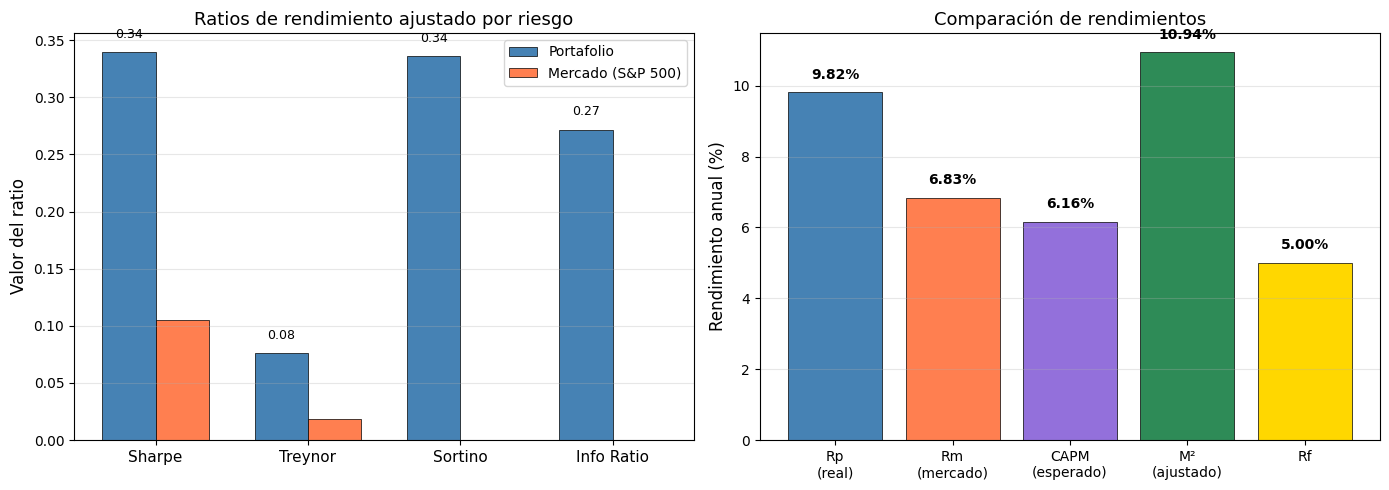

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ─── Panel 1: Ratios adimensionales (Sharpe, Treynor, Sortino, IR) ───
ax1 = axes[0]
ratios_nombres = ["Sharpe", "Treynor", "Sortino", "Info Ratio"]
ratios_port = [sharpe, treynor, sortino, info_ratio]
ratios_merc = [sharpe_mercado, treynor_mercado, None, None]

x = np.arange(len(ratios_nombres))
ancho = 0.35

barras_p = ax1.bar(x - ancho/2, ratios_port, ancho, label="Portafolio",
                   color="steelblue", edgecolor="black", linewidth=0.5)
barras_m = ax1.bar(x + ancho/2,
                   [v if v is not None else 0 for v in ratios_merc],
                   ancho, label="Mercado (S&P 500)",
                   color="coral", edgecolor="black", linewidth=0.5)

ax1.set_xticks(x)
ax1.set_xticklabels(ratios_nombres, fontsize=11)
ax1.set_ylabel("Valor del ratio", fontsize=12)
ax1.set_title("Ratios de rendimiento ajustado por riesgo", fontsize=13)
ax1.legend(fontsize=10)
ax1.axhline(0, color="black", linewidth=0.5)
ax1.grid(axis="y", alpha=0.3)

# Agregar valores sobre las barras
for bar in barras_p:
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f"{bar.get_height():.2f}", ha="center", va="bottom", fontsize=9)

# ─── Panel 2: Comparación de rendimientos (%) ───
ax2 = axes[1]
nombres_rend = ["Rp\n(real)", "Rm\n(mercado)", "CAPM\n(esperado)", "M²\n(ajustado)", "Rf"]
valores_rend = [Rp, Rm, Rp_capm, M2, rf_anual]
colores_rend = ["steelblue", "coral", "mediumpurple", "seagreen", "gold"]

barras = ax2.bar(nombres_rend, [v * 100 for v in valores_rend],
                 color=colores_rend, edgecolor="black", linewidth=0.5)
ax2.set_ylabel("Rendimiento anual (%)", fontsize=12)
ax2.set_title("Comparación de rendimientos", fontsize=13)
ax2.grid(axis="y", alpha=0.3)

for bar, val in zip(barras, valores_rend):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f"{val:.2%}", ha="center", va="bottom", fontsize=10, fontweight="bold")

plt.tight_layout()
plt.show()

---

## Conclusiones

### ¿Cuándo usar cada ratio?

| Situación | Ratio recomendado | ¿Por qué? |
|---|---|---|
| Evaluar un portafolio **único** | **Sharpe** | Usa riesgo total, aplicable siempre |
| Comparar portafolios **bien diversificados** | **Treynor** | Solo riesgo sistemático es relevante |
| Medir habilidad del **gestor** | **Alfa de Jensen** | ¿Generó valor sobre lo que predice el CAPM? |
| Preocupación por **pérdidas** | **Sortino** | Solo penaliza la volatilidad a la baja |
| Gestión **activa** vs. benchmark | **Information Ratio** | ¿Cuánto gana por desviarse del benchmark? |
| Comparar rendimientos en **términos absolutos** | **Modigliani (M²)** | Resultado en %, fácil de interpretar |

### Relación entre los ratios:

- **Sharpe** y **M²** están directamente relacionados: $M^2 = R_f + \text{Sharpe} \times \sigma_m$. Si el Sharpe es mayor que el del mercado, M² superará a $R_m$.
- **Treynor** y **Alfa de Jensen** usan el mismo riesgo ($\beta$), pero Jensen da una diferencia absoluta y Treynor un ratio.
- **Sortino** mejora al **Sharpe** al distinguir volatilidad buena (al alza) de mala (a la baja).
- El **Information Ratio** es independiente de los anteriores: mide **consistencia** en superar al benchmark.

> **Ningún ratio es suficiente por sí solo.** Un análisis robusto requiere evaluar varios ratios en conjunto para obtener una imagen completa del desempeño ajustado por riesgo.

---

## Taller: Medidas de Desempeño de Portafolios — Modelo CAPM

**Instrucciones generales:**  
Utilice las **mismas 5 acciones que seleccionó en el taller anterior**. Construya 3 portafolios: Uno con los pesos de su **portafolio tangente (máximo Sharpe)**, otro **portafolio equiponderado** (20% cada activo) y por ultimo uno con pesos elegidos por usted (de acuerdo con lo que opina de cada activo). Compare ambos entre sí y contra los resultados del portafolio equiponderado de este cuaderno (AAPL, JNJ, JPM, XOM, PG). Use el S&P 500 como benchmark y $r_f$ igual a la tasa que justificó en el taller anterior.

---

### Parte 1 — Datos y construcción de portafolios 

1. Descargue los precios de cierre diarios de sus 5 acciones y del S&P 500 para el mismo período que usó en el taller anterior.
2. Calcule los rendimientos logarítmicos diarios.
3. Construya **tres portafolios**:
   - **Portafolio A** — equiponderado (20% cada activo).
   - **Portafolio B** — con los pesos del portafolio tangente que obtuvo en el taller 6 con `PyPortfolioOpt`.
   - **Portafolio C** - con los pesos que usted considera a discreción

4. Calcule y presente las **estadísticas base anualizadas** de ambos portafolios: $R_p$, $\sigma_p$, $\beta_p$, $\sigma_{downside}$ y tracking error.

---

### Parte 2 — Ratio de Sharpe

5. Calcule el **ratio de Sharpe** de ambos portafolios y del mercado (S&P 500).
6. Muestre el desarrollo paso a paso de la fórmula: $\text{Sharpe} = \frac{R_p - R_f}{\sigma_p}$
7. **Pregunta:** ¿Cuál de sus dos portafolios tiene mejor relación riesgo-rendimiento? ¿Alguno supera al mercado? ¿Por qué era esperable (o no) ese resultado?

---

### Parte 3 — Ratio de Treynor 

8. Calcule el **ratio de Treynor** de ambos portafolios y del mercado.
9. Muestre el desarrollo: $\text{Treynor} = \frac{R_p - R_f}{\beta_p}$
10. **Pregunta:** ¿El ranking entre sus portafolios cambia al pasar de Sharpe a Treynor? Explique qué significa que un portafolio tenga mejor Treynor que Sharpe (o viceversa) y qué implica sobre la diversificación.

---

### Parte 4 — Alfa de Jensen 

11. Calcule el **Alfa de Jensen** de ambos portafolios: $\alpha_p = R_p - [R_f + \beta_p (R_m - R_f)]$
12. Muestre el rendimiento esperado según el CAPM y compare con el rendimiento real.
13. **Pregunta:** ¿Sus portafolios generaron valor sobre lo que predice el modelo CAPM? Si obtiene un alfa negativo, ¿significa que el portafolio fue "malo"? Argumente.

---

### Parte 5 — Ratio de Sortino 

14. Calcule la **downside deviation** de ambos portafolios (usando solo los rendimientos en exceso negativos).
15. Calcule el **ratio de Sortino**: $\text{Sortino} = \frac{R_p - R_f}{\sigma_{downside}}$
16. Compare con el Sharpe de cada portafolio.
17. **Pregunta:** ¿Su Sortino es mayor o menor que el Sharpe? ¿Qué le indica esto sobre la distribución de los rendimientos de su portafolio (¿asimetría positiva o negativa?)?

---

### Parte 6 — Ratio de Información 

18. Calcule el **rendimiento activo** ($R_p - R_m$) y el **tracking error** de ambos portafolios.
19. Calcule el **Information Ratio**: $IR = \frac{R_p - R_m}{\text{Tracking Error}}$
20. **Pregunta:** ¿Cuál portafolio es más consistente en superar (o quedar debajo) del benchmark? ¿Un tracking error alto es necesariamente malo? Explique.

---

### Parte 7 — Medida de Modigliani M² 

21. Calcule la **medida M²** de ambos portafolios: $M^2 = R_f + \text{Sharpe}_p \times \sigma_m$
22. Compare $M^2$ con el rendimiento del mercado $R_m$.
23. **Pregunta:** Si su $M^2 > R_m$, ¿qué significa en palabras simples? ¿Cómo se relaciona M² con el ratio de Sharpe?

---

### Parte 8 — Tabla resumen y comparación 

24. Construya una **tabla resumen** con los 6 ratios para:

| Ratio | Portafolio A (equiponderado) | Portafolio B (tangente) | Mercado (S&P 500) | Portafolio ejemplo (este cuaderno) |
|---|---|---|---|---|
| Sharpe | | | | |
| Treynor | | | | |
| Alfa de Jensen | | | | |
| Sortino | | | | |
| Information Ratio | | | | |
| M² | | | | |

25. Para la columna "Portafolio ejemplo", use los valores calculados en este cuaderno:
    - El portafolio equiponderado de AAPL, JNJ, JPM, XOM, PG (2022-2025)
    
26. Cree un **gráfico de barras doble** (como el de este cuaderno) comparando sus dos portafolios y el mercado en todos los ratios.

---

### Parte 9 — Análisis integral y conclusiones 

27. Responda las siguientes preguntas en celdas Markdown:

    a) **Sharpe vs. Treynor:** ¿Ambos ratios dan el mismo ranking entre sus portafolios? Si difieren, ¿qué le dice sobre el riesgo no sistemático de cada portafolio?

    b) **Sortino vs. Sharpe:** ¿Su portafolio tiene más volatilidad al alza o a la baja? ¿Cómo afecta esto la percepción de riesgo?

    c) **Alfa de Jensen:** ¿Alguno de sus portafolios logró generar valor por encima del CAPM? ¿Qué factores podrían explicar un alfa positivo (o negativo)?

    d) **Comparación con el portafolio del cuaderno:** ¿Su portafolio tangente es mejor o peor que el equiponderado de este cuaderno? ¿En qué métricas gana y en cuáles pierde?

    e) **¿Cuál ratio usaría usted?** Si tuviera que elegir UN SOLO ratio para evaluar su portafolio, ¿cuál elegiría y por qué? Justifique según las características de su portafolio.

28. Redacte unas **conclusiones generales** (mínimo 8 líneas) que integren:
    - La comparación entre portafolio equiponderado vs. tangente
    - Qué métricas favorecen a cada uno y por qué
    - Qué aprendió sobre la relación entre diversificación y las diferentes medidas de riesgo
